In [ ]:
#Import libraries
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np


In [ ]:
#T-bill for risk-free rate
from google.colab import files
files.upload()

Saving rbi_tbill_91d.csv to rbi_tbill_91d (1).csv


{'rbi_tbill_91d (1).csv': b'\xef\xbb\xbfPeriod,910Day Treasury Bill (Primary) Yield (%)\r\n03-Apr-2026,0\r\n27-Mar-2026,0\r\n20-Mar-2026,5.33\r\n13-Mar-2026,5.32\r\n06-Mar-2026,5.31\r\n27-Feb-2026,5.30\r\n20-Feb-2026,5.32\r\n13-Feb-2026,5.32\r\n06-Feb-2026,5.34\r\n30-Jan-2026,5.50\r\n23-Jan-2026,5.49\r\n16-Jan-2026,5.34\r\n09-Jan-2026,5.31\r\n02-Jan-2026,0\r\n26-Dec-2025,5.26\r\n19-Dec-2025,5.28\r\n12-Dec-2025,5.27\r\n05-Dec-2025,5.35\r\n28-Nov-2025,5.36\r\n21-Nov-2025,5.38\r\n14-Nov-2025,5.43\r\n07-Nov-2025,5.45\r\n31-Oct-2025,5.46\r\n24-Oct-2025,5.46\r\n17-Oct-2025,5.44\r\n10-Oct-2025,5.43\r\n03-Oct-2025,5.49\r\n26-Sep-2025,5.47\r\n19-Sep-2025,5.50\r\n12-Sep-2025,5.51\r\n05-Sep-2025,5.51\r\n29-Aug-2025,5.51\r\n22-Aug-2025,5.48\r\n15-Aug-2025,5.49\r\n08-Aug-2025,5.46\r\n01-Aug-2025,5.40\r\n25-Jul-2025,5.39\r\n18-Jul-2025,5.39\r\n11-Jul-2025,5.39\r\n04-Jul-2025,5.37\r\n27-Jun-2025,5.41\r\n20-Jun-2025,5.36\r\n13-Jun-2025,5.37\r\n06-Jun-2025,5.58\r\n30-May-2025,5.62\r\n23-May-2025,5.71\r

In [ ]:
# Load RBI DBIE download
tbill = pd.read_csv("rbi_tbill_91d.csv", skiprows=0)
tbill.columns = ['Date', 'Yield']
tbill['Date'] = pd.to_datetime(tbill['Date'], dayfirst=True)
tbill['Yield'] = pd.to_numeric(tbill['Yield'], errors='coerce')

# Clean data: Filter out 0.0 values and NaNs which are placeholders/errors
tbill = tbill[tbill['Yield'] > 0].dropna()

tbill = tbill.set_index('Date')

# Average yield over sample period
rf_annual = tbill['Yield'].mean() / 100
rf_daily  = rf_annual / 252

print(f"Risk-free rate from RBI DBIE: {rf_annual:.4%} p.a.")
print(f"Daily equivalent: {rf_daily:.6f}")

Risk-free rate from RBI DBIE: 5.4930% p.a.
Daily equivalent: 0.000218


In [ ]:

# 1. Define Indian stock and market index
stock_symbols=  ['RELIANCE.NS', 'INFY.NS', 'ZEELEARN.NS', 'RAYMOND.NS', 'HAL.NS']    # Reliance Industries, Infosys, Zee Learn, Raymond and Hindustan Aeronautics
market_symbol = '^NSEI'         # NIFTY 50 index

# 2. Download historical data
start_date = '2025-04-01'
end_date = '2026-03-31'

stock_data = yf.download(stock_symbols, start=start_date, end=end_date)['Close']
market_data = yf.download(market_symbol, start=start_date, end=end_date)['Close']
print(stock_data.head())
print(market_data.head())

/tmp/ipykernel_1988/1698527605.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(stock_symbols, start=start_date, end=end_date)['Close']
[*********************100%***********************]  5 of 5 completed
/tmp/ipykernel_1988/1698527605.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market_data = yf.download(market_symbol, start=start_date, end=end_date)['Close']
[*********************100%***********************]  1 of 1 completed

Ticker           HAL.NS      INFY.NS   RAYMOND.NS  RELIANCE.NS  ZEELEARN.NS
Date                                                                       
2025-04-01  4174.835449  1482.622681  1373.750000  1247.617065         5.47
2025-04-02  4185.411621  1505.593018  1413.300049  1246.172974         5.99
2025-04-03  4269.230469  1453.485107  1499.199951  1243.732666         6.34
2025-04-04  4190.057129  1409.924316  1484.550049  1199.907593         6.36
2025-04-07  3961.828125  1356.602295  1436.949951  1161.062744         6.00
Ticker             ^NSEI
Date                    
2025-04-01  23165.699219
2025-04-02  23332.349609
2025-04-03  23250.099609
2025-04-04  22904.449219
2025-04-07  22161.599609


In [ ]:
# 2. Download historical data
stock_data = yf.download(stock_symbols, start=start_date, end=end_date)['Close']
market_data = yf.download(market_symbol, start=start_date, end=end_date)['Close']

# 3. Calculate daily returns
stock_returns = stock_data.pct_change().dropna()
market_returns = market_data.pct_change().dropna()

# 4. Convert to Excess Returns
stock_excess = stock_returns.subtract(rf_daily, axis=0)
market_excess = market_returns - rf_daily

# --- FIX START ---
# Force market_excess to be a Series named 'Market'
if isinstance(market_excess, pd.DataFrame):
    market_excess = market_excess.iloc[:, 0] # Take the first column if it's a DF
market_excess.name = 'Market'

# Join them
excess_df = stock_excess.join(market_excess).dropna()
# --- FIX END ---

print("Columns in excess_df:", excess_df.columns.tolist())
print(excess_df.head())

/tmp/ipykernel_1988/2449092203.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(stock_symbols, start=start_date, end=end_date)['Close']
[*********************100%***********************]  5 of 5 completed
/tmp/ipykernel_1988/2449092203.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market_data = yf.download(market_symbol, start=start_date, end=end_date)['Close']
[*********************100%***********************]  1 of 1 completed

Columns in excess_df: ['HAL.NS', 'INFY.NS', 'RAYMOND.NS', 'RELIANCE.NS', 'ZEELEARN.NS', 'Market']
              HAL.NS   INFY.NS  RAYMOND.NS  RELIANCE.NS  ZEELEARN.NS    Market
Date                                                                          
2025-04-02  0.002315  0.015275    0.028572    -0.001375     0.094846  0.006976
2025-04-03  0.019808 -0.034828    0.060562    -0.002176     0.058213 -0.003743
2025-04-04 -0.018763 -0.030188   -0.009990    -0.035455     0.002937 -0.015085
2025-04-07 -0.054687 -0.038037   -0.032282    -0.032591    -0.056822 -0.032651
2025-04-08  0.008202  0.022728    0.014675     0.013937     0.041449  0.016669



/tmp/ipykernel_1988/2449092203.py:6: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  stock_returns = stock_data.pct_change().dropna()


In [ ]:
results = []
# X must be the 'Market' column from our joined dataframe
X = sm.add_constant(excess_df['Market'])

for stock in stock_symbols:
    y = excess_df[stock]
    model = sm.OLS(y, X).fit()

    results.append({
        'Ticker': stock,
        'Alpha': model.params['const'],
        'Beta': model.params['Market'],
        'Residual_Var': model.mse_resid,
        'R_Squared': model.rsquared
    })

input_list_df = pd.DataFrame(results)
print("--- Markowitz Input List (SIM) ---")
print(input_list_df)

--- Markowitz Input List (SIM) ---
        Ticker     Alpha      Beta  Residual_Var  R_Squared
0  RELIANCE.NS  0.000498  0.993273      0.000096   0.426405
1      INFY.NS -0.000473  0.930837      0.000201   0.236912
2  ZEELEARN.NS -0.000448  0.916891      0.000970   0.058878
3   RAYMOND.NS -0.003876  1.091183      0.002215   0.037338
4       HAL.NS -0.000499  0.901932      0.000251   0.189402


In [ ]:
# 1. Calculate Market Statistics (Daily)
market_mean = excess_df['Market'].mean()
market_var = excess_df['Market'].var()

# 2. Calculate Expected Excess Returns for each stock
# Formula: E(Ri) = Alpha + Beta * E(Rm)
input_list_df['Expected_Return'] = input_list_df['Alpha'] + (input_list_df['Beta'] * market_mean)

# 3. Calculate Individual Variances (for the diagonal of the matrix)
# Formula: Var(i) = Beta^2 * Var(Market) + Residual_Var
input_list_df['Total_Var'] = (input_list_df['Beta']**2 * market_var) + input_list_df['Residual_Var']

print("--- Final Input List (Daily) ---")
print(input_list_df[['Ticker', 'Expected_Return', 'Total_Var']])

--- Final Input List (Daily) ---
        Ticker  Expected_Return  Total_Var
0  RELIANCE.NS         0.000168   0.000167
1      INFY.NS        -0.000782   0.000264
2  ZEELEARN.NS        -0.000753   0.001030
3   RAYMOND.NS        -0.004238   0.002301
4       HAL.NS        -0.000798   0.000310


In [ ]:
#Construct the SIM Covariance Matrix
tickers = input_list_df['Ticker'].tolist()
n = len(tickers)
cov_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        if i == j:
            # Diagonal elements use the Total Variance formula
            cov_matrix[i, j] = input_list_df.loc[i, 'Total_Var']
        else:
            # Off-diagonal elements use the SIM covariance formula
            cov_matrix[i, j] = input_list_df.loc[i, 'Beta'] * input_list_df.loc[j, 'Beta'] * market_var

# Convert to DataFrame for readability
cov_matrix_df = pd.DataFrame(cov_matrix, index=tickers, columns=tickers)

print("\n--- SIM Covariance Matrix ---")
print(cov_matrix_df)


--- SIM Covariance Matrix ---
             RELIANCE.NS   INFY.NS  ZEELEARN.NS  RAYMOND.NS    HAL.NS
RELIANCE.NS     0.000167  0.000066     0.000065    0.000078  0.000064
INFY.NS         0.000066  0.000264     0.000061    0.000073  0.000060
ZEELEARN.NS     0.000065  0.000061     0.001030    0.000072  0.000059
RAYMOND.NS      0.000078  0.000073     0.000072    0.002301  0.000071
HAL.NS          0.000064  0.000060     0.000059    0.000071  0.000310


In [ ]:
# ── Part 1(b) ── Efficient Frontier & Tangency Portfolio
# ─────────────────────────────────────────────────────────────────────────────
# STEP 1: Annualise the SIM inputs
# All quantities so far are DAILY.  Multiply by 252 to annualise:
#   Expected return  →  × 252
#   Variance         →  × 252   (so std dev × √252)
#   Covariance       →  × 252

In [ ]:
TRADING_DAYS = 252

# Annualised expected EXCESS returns vector (μ_e)
mu_excess_annual = input_list_df['Expected_Return'].values * TRADING_DAYS

# Annualised total expected returns (add back rf)
mu_annual = mu_excess_annual + rf_annual          # shape (n,)

# Annualised covariance matrix
cov_annual = cov_matrix * TRADING_DAYS            # shape (n, n)

# Annualised risk-free rate (already stored as rf_annual)
print(f"Risk-free rate (annual):        {rf_annual:.4%}")
print(f"\nAnnualised Expected Returns:")
for t, r in zip(tickers, mu_annual):
    print(f"  {t:15s}  {r:.4%}")
print(f"\nAnnualised Covariance Matrix:")
print(pd.DataFrame(cov_annual, index=tickers, columns=tickers).round(6))

Risk-free rate (annual):        5.4930%

Annualised Expected Returns:
  RELIANCE.NS      9.7326%
  INFY.NS          -14.2059%
  ZEELEARN.NS      -13.4739%
  RAYMOND.NS       -101.3035%
  HAL.NS           -14.6258%

Annualised Covariance Matrix:
             RELIANCE.NS   INFY.NS  ZEELEARN.NS  RAYMOND.NS    HAL.NS
RELIANCE.NS     0.042002  0.016745     0.016494    0.019629  0.016225
INFY.NS         0.016745  0.066444     0.015457    0.018395  0.015205
ZEELEARN.NS     0.016494  0.015457     0.259595    0.018120  0.014977
RAYMOND.NS      0.019629  0.018395     0.018120    0.579816  0.017824
HAL.NS          0.016225  0.015205     0.014977    0.017824  0.078044


In [ ]:
# STEP 2: Portfolio statistics helper functions

def port_return(w, mu):
    """Expected return of a portfolio."""
    return w @ mu

def port_vol(w, cov):
    """Annualised portfolio volatility."""
    return np.sqrt(w @ cov @ w)

def port_sharpe(w, mu, cov, rf):
    """Sharpe ratio of a portfolio."""
    return (port_return(w, mu) - rf) / port_vol(w, cov)

n_assets = len(tickers)
w0 = np.ones(n_assets) / n_assets    # equal-weight starting guess

# Constraints: weights sum to 1  (long-only: bounds 0 ≤ w ≤ 1)
constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
bounds      = [(0, 1)] * n_assets

print("Helper functions defined. n_assets =", n_assets)

Helper functions defined. n_assets = 5


In [ ]:
# STEP 3: Minimum-Variance Portfolio (MVP)
# The MVP sits at the leftmost point of the efficient frontier.
# We minimise portfolio variance subject to weights summing to 1.

from scipy.optimize import minimize

mvp_result = minimize(
    fun     = lambda w: port_vol(w, cov_annual),
    x0      = w0,
    method  = 'SLSQP',
    bounds  = bounds,
    constraints = constraints
)

w_mvp    = mvp_result.x
ret_mvp  = port_return(w_mvp, mu_annual)
vol_mvp  = port_vol(w_mvp, cov_annual)
sr_mvp   = port_sharpe(w_mvp, mu_annual, cov_annual, rf_annual)

print("=== Minimum Variance Portfolio ===")
print(f"  Expected Return : {ret_mvp:.4%}")
print(f"  Volatility (σ)  : {vol_mvp:.4%}")
print(f"  Sharpe Ratio    : {sr_mvp:.4f}")
print("\n  Weights:")
for t, w in zip(tickers, w_mvp):
    print(f"    {t:15s}  {w:.4%}")

=== Minimum Variance Portfolio ===
  Expected Return : -4.3786%
  Volatility (σ)  : 16.9400%
  Sharpe Ratio    : -0.5827

  Weights:
    RELIANCE.NS      47.6308%
    INFY.NS          24.8380%
    ZEELEARN.NS      5.1835%
    RAYMOND.NS       1.7523%
    HAL.NS           20.5953%


In [ ]:
# STEP 4: Tangency Portfolio (Maximum Sharpe Ratio)
# The tangency portfolio is where the Capital Market Line (CML) is tangent
# to the risky-asset efficient frontier.  It maximises the Sharpe ratio.
#
# Closed-form solution (no short-selling):
#   z  = Σ⁻¹ (μ - rf·1)
#   w* = z / sum(z)      [then clip negatives for long-only version]
#
# We also solve it via optimisation to handle the long-only constraint.

# ── Closed-form (unconstrained, for reference) ──
Sigma_inv   = np.linalg.inv(cov_annual)
excess_mu   = mu_annual - rf_annual
z_unconstrained = Sigma_inv @ excess_mu
w_tangency_unconstrained = z_unconstrained / z_unconstrained.sum()

print("Tangency weights (unconstrained / may include short positions):")
for t, w in zip(tickers, w_tangency_unconstrained):
    print(f"  {t:15s}  {w:+.4%}")

# ── Long-only tangency via optimisation ──
tang_result = minimize(
    fun     = lambda w: -port_sharpe(w, mu_annual, cov_annual, rf_annual),
    x0      = w0,
    method  = 'SLSQP',
    bounds  = bounds,
    constraints = constraints
)

w_tang   = tang_result.x
ret_tang = port_return(w_tang, mu_annual)
vol_tang = port_vol(w_tang, cov_annual)
sr_tang  = port_sharpe(w_tang, mu_annual, cov_annual, rf_annual)

print("\n=== Tangency Portfolio (Long-Only) ===")
print(f"  Expected Return : {ret_tang:.4%}")
print(f"  Volatility (σ)  : {vol_tang:.4%}")
print(f"  Sharpe Ratio    : {sr_tang:.4f}")
print("\n  Weights:")
for t, w in zip(tickers, w_tang):
    print(f"    {t:15s}  {w:.4%}")


Tangency weights (unconstrained / may include short positions):
  RELIANCE.NS      -119.4423%
  INFY.NS          +82.2296%
  ZEELEARN.NS      +16.3027%
  RAYMOND.NS       +52.3084%
  HAL.NS           +68.6017%

=== Tangency Portfolio (Long-Only) ===
  Expected Return : 9.7326%
  Volatility (σ)  : 20.4944%
  Sharpe Ratio    : 0.2069

  Weights:
    RELIANCE.NS      100.0000%
    INFY.NS          0.0000%
    ZEELEARN.NS      0.0000%
    RAYMOND.NS       0.0000%
    HAL.NS           0.0000%


In [ ]:
# STEP 5: Trace the Efficient Frontier
# We sweep target returns from MVP return upward, minimising variance at each target. This gives us the upper (efficient) half of the frontier.

target_returns = np.linspace(ret_mvp, max(mu_annual) * 1.05, 200)

frontier_vols = []
frontier_rets = []

for target in target_returns:
    cons = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w, t=target: port_return(w, mu_annual) - t}
    ]
    res = minimize(
        fun     = lambda w: port_vol(w, cov_annual),
        x0      = w0,
        method  = 'SLSQP',
        bounds  = bounds,
        constraints = cons
    )
    if res.success:
        frontier_vols.append(res.fun)
        frontier_rets.append(target)

frontier_vols = np.array(frontier_vols)
frontier_rets = np.array(frontier_rets)
print(f"Efficient frontier traced: {len(frontier_rets)} points")

Efficient frontier traced: 193 points


In [ ]:
# STEP 6: Capital Market Line (CML)
# CML passes through (σ=0, rf) and the tangency portfolio.
# All portfolios on the CML are combinations of the risk-free asset and
# the tangency portfolio.
#
# CML equation:  E(Rp) = rf  +  [(E(Rt) - rf) / σt] × σp
#                              ╰────── slope = Sharpe of tangency ──────╯

cml_vols = np.linspace(0, max(frontier_vols) * 1.3, 300)
cml_rets = rf_annual + sr_tang * cml_vols

print(f"CML slope (Sharpe of tangency portfolio): {sr_tang:.4f}")
print(f"  Intercept (rf):  {rf_annual:.4%}")
print(f"  At tangency:     σ = {vol_tang:.4%}, E(R) = {ret_tang:.4%}")


CML slope (Sharpe of tangency portfolio): 0.2069
  Intercept (rf):  5.4930%
  At tangency:     σ = 20.4944%, E(R) = 9.7326%


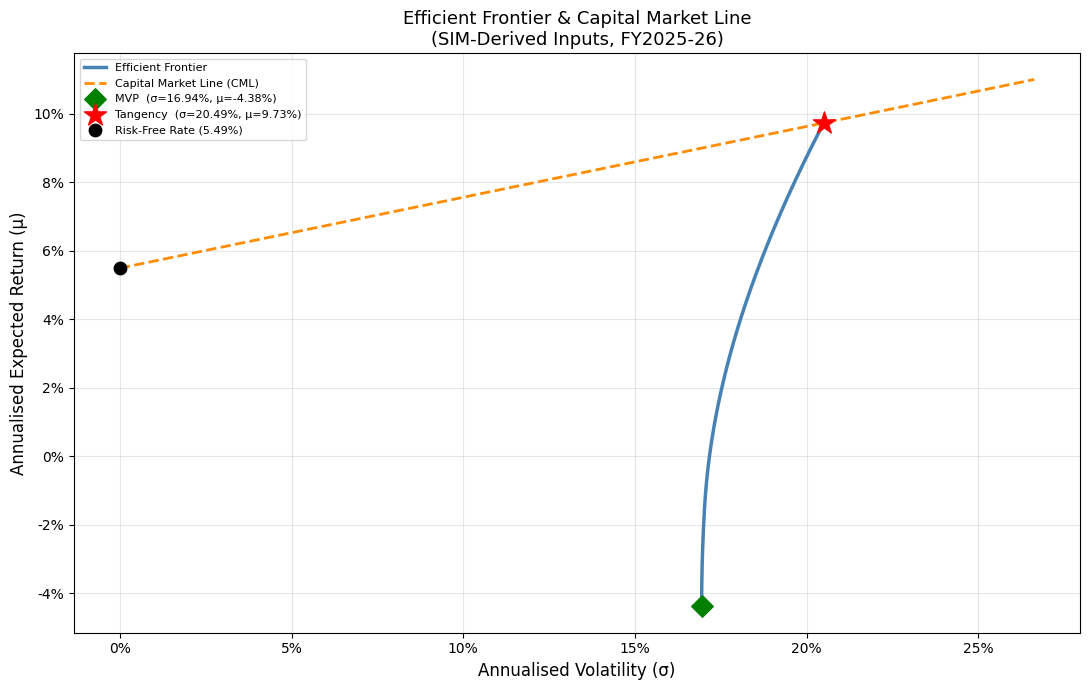

In [ ]:
# STEP 7: Plot — Efficient Frontier, CML, MVP, Tangency Portfolio

fig, ax = plt.subplots(figsize=(11, 7))

# ── Efficient frontier ──
ax.plot(frontier_vols, frontier_rets,
        color='steelblue', linewidth=2.5, label='Efficient Frontier')

# ── Capital Market Line ──
ax.plot(cml_vols, cml_rets,
        color='darkorange', linewidth=2, linestyle='--', label='Capital Market Line (CML)')

# ── MVP ──
ax.scatter(vol_mvp, ret_mvp,
           marker='D', s=120, color='green', zorder=6,
           label=f'MVP  (σ={vol_mvp:.2%}, μ={ret_mvp:.2%})')

# ── Tangency portfolio ──
ax.scatter(vol_tang, ret_tang,
           marker='*', s=280, color='red', zorder=7,
           label=f'Tangency  (σ={vol_tang:.2%}, μ={ret_tang:.2%})')

# ── Risk-free rate ──
ax.scatter(0, rf_annual, marker='o', s=80, color='black', zorder=6,
           label=f'Risk-Free Rate ({rf_annual:.2%})')

ax.set_xlabel('Annualised Volatility (σ)', fontsize=12)
ax.set_ylabel('Annualised Expected Return (μ)', fontsize=12)
ax.set_title('Efficient Frontier & Capital Market Line\n(SIM-Derived Inputs, FY2025-26)', fontsize=13)
ax.legend(fontsize=8, loc='upper left')
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()


In [ ]:
# STEP 8: Summary Table — Key Portfolios

summary = pd.DataFrame({
    'Portfolio'       : ['Risk-Free Asset', 'MVP', 'Tangency (Max Sharpe)'],
    'Expected Return' : [f'{rf_annual:.4%}',  f'{ret_mvp:.4%}',  f'{ret_tang:.4%}'],
    'Volatility (σ)'  : ['0.0000%',            f'{vol_mvp:.4%}',  f'{vol_tang:.4%}'],
    'Sharpe Ratio'    : ['—',                  f'{sr_mvp:.4f}',   f'{sr_tang:.4f}'],
})
print(summary.to_string(index=False))

print("\n=== Tangency Portfolio Weights ===")
tang_weights_df = pd.DataFrame({
    'Stock'  : tickers,
    'Weight' : [f'{w:.4%}' for w in w_tang],
    'Sector' : ['Energy/Conglomerates','IT','Education/Media','Textiles','Defence']
})
print(tang_weights_df.to_string(index=False))


            Portfolio Expected Return Volatility (σ) Sharpe Ratio
      Risk-Free Asset         5.4930%        0.0000%            —
                  MVP        -4.3786%       16.9400%      -0.5827
Tangency (Max Sharpe)         9.7326%       20.4944%       0.2069

=== Tangency Portfolio Weights ===
      Stock    Weight               Sector
RELIANCE.NS 100.0000% Energy/Conglomerates
    INFY.NS   0.0000%                   IT
ZEELEARN.NS   0.0000%      Education/Media
 RAYMOND.NS   0.0000%             Textiles
     HAL.NS   0.0000%              Defence
